In [1]:
import cafe
import scanpy as sc

cafe.settings.backend = "conda"
cafe.logger.setLevel("INFO")

[07/16/2025 11:07:50] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

数据

In [2]:
cluster_key = "clusters"
fadata = cafe.data.read_pancrease(n_obs=500 ,save_cluster_key=cluster_key)
fadata

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

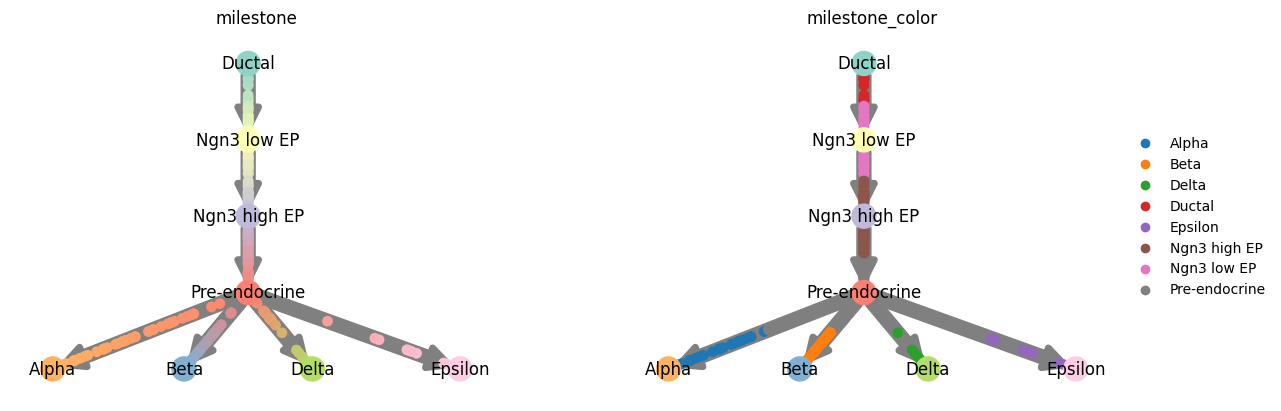

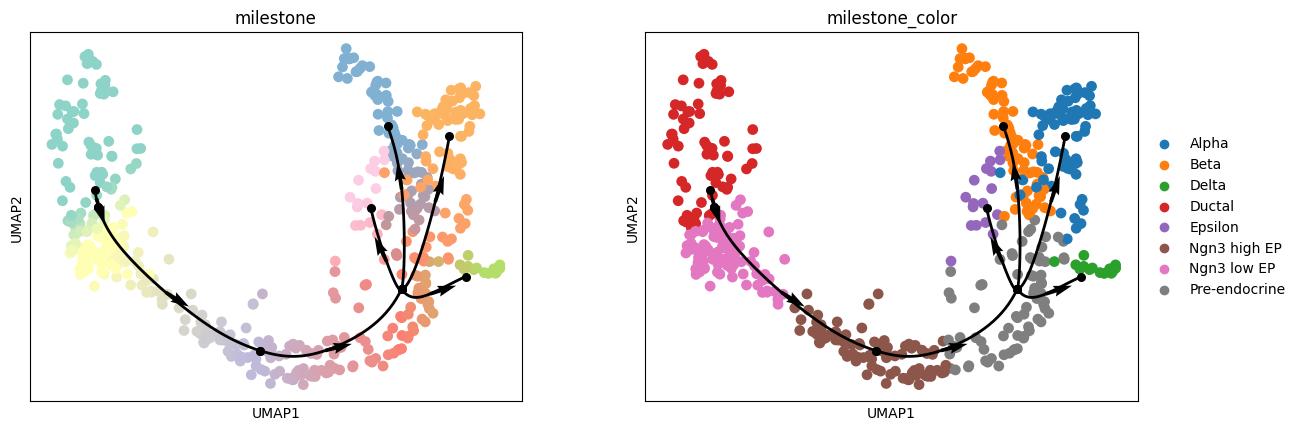

In [3]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cafe.plot.plot_graph(fadata, color=cluster_key_list)
cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[07/16/2025 11:07:56] INFO     method_backend: <cafe.method.fate_conda_backend.CondaBackend object at 0x7602e1294790>                                                                                    
[07/16/2025 11:07:59] INFO     [stdout]Normalized count data: X, spliced, unspliced.                                                                                                                    
                      INFO     [stdout]Logarithmized X.                                                                                                                                                 
[07/16/2025 11:08:01] INFO     [stdout]cf_paga finish!                                                                                                                                                  
[07/16/2025 11:08:02] INFO     method_backend: <cafe.method.fate_conda_backend.CondaBackend object at 0x7602e0d074c0>                                                                              

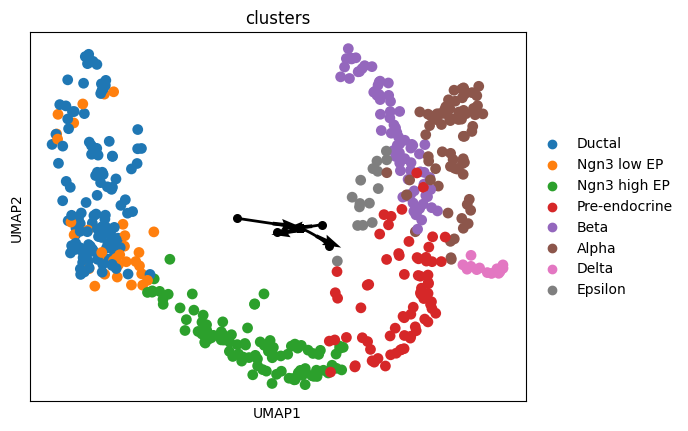

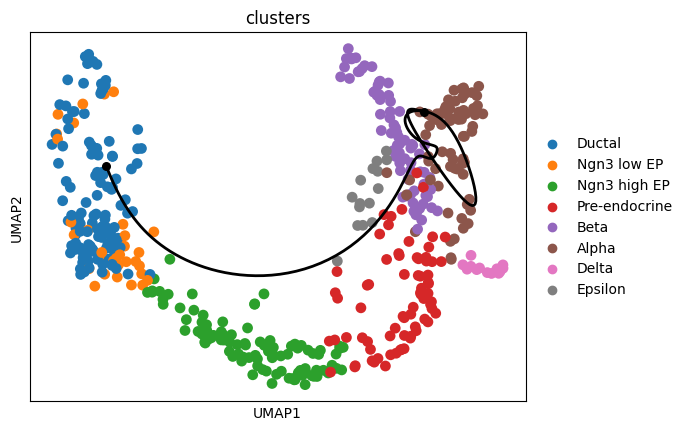

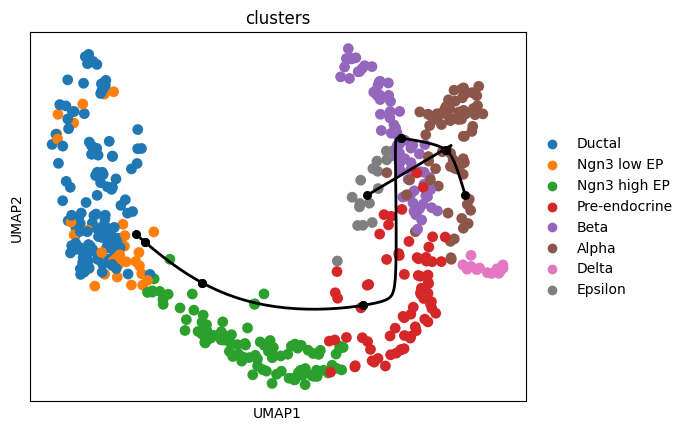

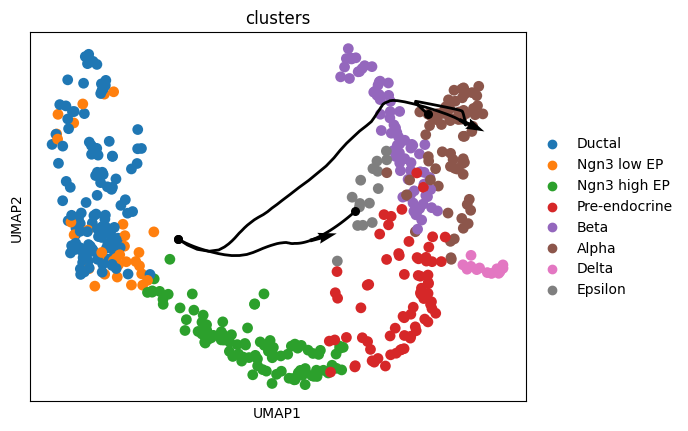

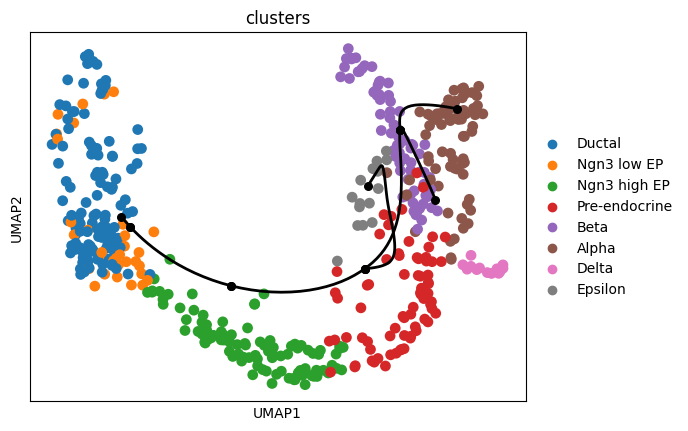

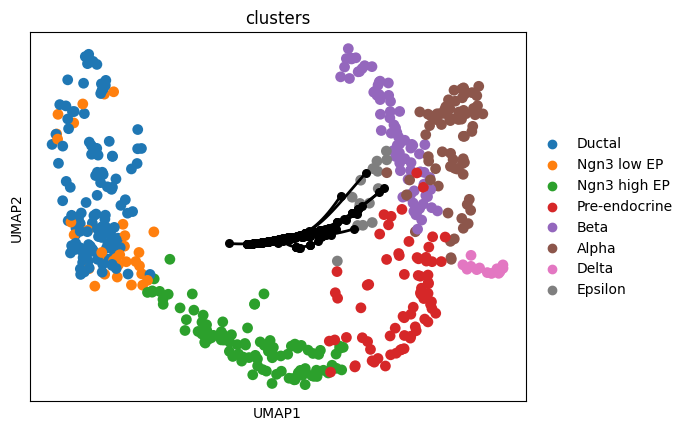

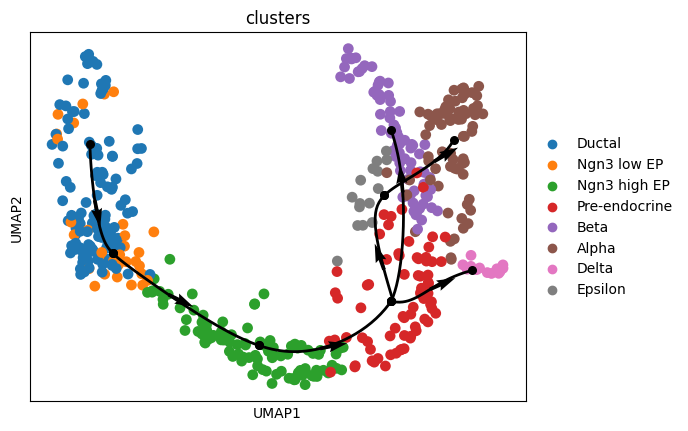

In [4]:
basis = "umap"
cluster_key = "clusters"

prior_information = {"start_id": "cell_000", "groups_id": fadata.obs[cluster_key].tolist()}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
parameters = {}

method_name_list = ["paga", "comp1", "cluster_mst", "state_comp", "projection_mst", "graph_mst", "scvelo"]

for method_name in method_name_list:
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key)